In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal.windows import hann, hamming, blackman

# Signal: on-bin tone so all energy lands in one bin
fs = 1000
N = 1024
k = 50                       # bin index
f0 = k * fs / N              # on-bin frequency
t = np.arange(N) / fs
x = np.cos(2*np.pi*f0*t)     # unit amplitude

windows = {
    'rect':     np.ones(N),
    'hann':     hann(N, sym=False),
    'hamming':  hamming(N, sym=False),
    'blackman': blackman(N, sym=False),
}

print(f"{'window':<10} {'CG (mean)':>10} {'peak |X[k]|':>14} {'peak/(N/2)':>12}")
for name, w in windows.items():
    cg = w.mean()
    X = fft(x * w)
    peak = np.abs(X[k])
    # For a unit-amplitude cosine: |X[k]| = (N/2) * CG
    print(f"{name:<10} {cg:>10.4f} {peak:>14.2f} {peak/(N/2):>12.4f}")

window      CG (mean)    peak |X[k]|   peak/(N/2)
rect           1.0000         512.00       1.0000
hann           0.5000         256.00       0.5000
hamming        0.5400         276.48       0.5400
blackman       0.4200         215.04       0.4200


In [7]:
def enbw_bins(w):
    return len(w) * np.sum(w**2) / (np.sum(w))**2

print(f"{'window':<10} {'CG':>8} {'ENBW (bins)':>14}")
for name, w in windows.items():
    print(f"{name:<10} {w.mean():>8.4f} {enbw_bins(w):>14.4f}")

window           CG    ENBW (bins)
rect         1.0000         1.0000
hann         0.5000         1.5000
hamming      0.5400         1.3628
blackman     0.4200         1.7268


In [8]:
print(f"{'window':<10} {'CG':>8} {'ENBW':>8} {'loss (dB)':>12}")
for name, w in windows.items():
    cg = w.mean()
    enbw = enbw_bins(w)
    loss_db = 10*np.log10(enbw / cg**2)
    print(f"{name:<10} {cg:>8.4f} {enbw:>8.4f} {loss_db:>12.3f}")

window           CG     ENBW    loss (dB)
rect         1.0000   1.0000        0.000
hann         0.5000   1.5000        7.782
hamming      0.5400   1.3628        6.697
blackman     0.4200   1.7268        9.907


In [9]:
def complex_gaussian_noise(N, power=1.0, rng=None):
    """Generate complex Gaussian noise with specified total power."""
    if rng is None:
        rng = np.random.default_rng()
    sigma = np.sqrt(power / 2)
    return rng.normal(0, sigma, N) + 1j*rng.normal(0, sigma, N)

rng = np.random.default_rng(42)
n = complex_gaussian_noise(100_000, power=1.0, rng=rng)

print(f"Mean of |n|^2: {np.mean(np.abs(n)**2):.4f}  (should be ~1.0)")
print(f"Var of Re(n): {np.var(n.real):.4f}     (should be ~0.5)")
print(f"Var of Im(n): {np.var(n.imag):.4f}     (should be ~0.5)")

Mean of |n|^2: 1.0055  (should be ~1.0)
Var of Re(n): 0.5037     (should be ~0.5)
Var of Im(n): 0.5018     (should be ~0.5)


In [10]:
fs = 1000
N = 4096
k = 100
f0 = k * fs / N
t = np.arange(N) / fs
A = 1.0
target_snr_db = 0.0          # signal power == noise power

signal_power = A**2 / 2
noise_power = signal_power / 10**(target_snr_db/10)

rng = np.random.default_rng(0)
s = A * np.cos(2*np.pi*f0*t)
n = complex_gaussian_noise(N, power=noise_power, rng=rng)
x = s + n                    # complex-valued

# Measure SNR in the time domain
measured_signal_power = np.mean(s**2)
measured_noise_power  = np.mean(np.abs(n)**2)
measured_snr_db = 10*np.log10(measured_signal_power / measured_noise_power)

print(f"Target SNR:   {target_snr_db:6.2f} dB")
print(f"Measured SNR: {measured_snr_db:6.2f} dB")

Target SNR:     0.00 dB
Measured SNR:  -0.01 dB


In [18]:
import numpy as np
from scipy.fft import fft
from scipy.signal.windows import hann

fs = 1000
N = 4096
k = 100
f0 = k * fs / N
t = np.arange(N) / fs
A = 1.0
target_snr_db = 10
signal_power = A**2 / 2
noise_power = signal_power / 10**(target_snr_db / 10)

rng = np.random.default_rng(0)
s = A * np.cos(2*np.pi*f0*t)
n = complex_gaussian_noise(N, power=noise_power, rng=rng)
x = s + n

windows = {
    'rect': np.ones(N),
    'hann': hann(N, sym=False),
}

print(f"{'window':<8} {'bin-SNR (dB)':>14}")
for name, w in windows.items():
    X = fft(x * w)
    power = np.abs(X)**2                # power per bin

    signal_bin_power = power[k]         # signal sits in bin k

    # mask out the signal bin and a few neighbors (leakage zone)
    mask = np.ones(N, dtype=bool)
    mask[k-3:k+4] = False               # exclude bin k and ±3 neighbors
    mask[N-k-3:N-k+4] = False           # also the mirror bin (real signal)
    noise_bin_power = np.median(power[mask])

    bin_snr_db = 10 * np.log10(signal_bin_power / noise_bin_power)
    print(f"{name:<8} {bin_snr_db:>14.3f}")

window     bin-SNR (dB)
rect             44.646
hann             42.904


       N   mean SNR (dB)    std SNR (dB)
      64          0.0106          0.5007
     256         -0.0264          0.2600
    1024          0.0044          0.1375
    4096          0.0020          0.0625
   16384          0.0027          0.0361

Fitted slope on log-log axes: -0.482  (expected near -0.5)


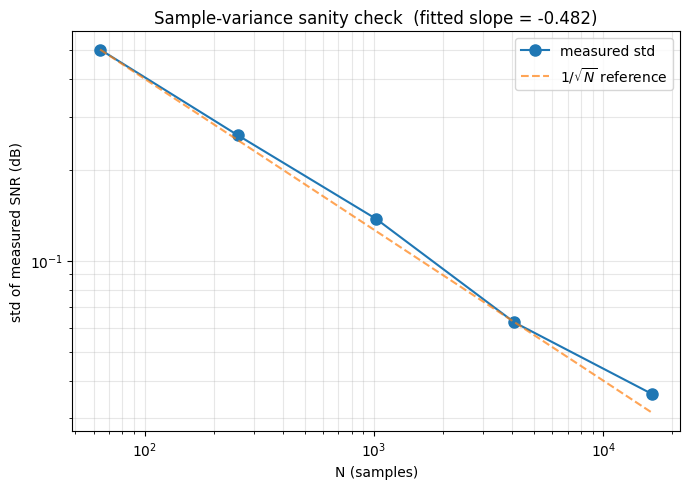

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def complex_gaussian_noise(N, power=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    sigma = np.sqrt(power / 2)
    return rng.normal(0, sigma, N) + 1j*rng.normal(0, sigma, N)

# Parameters
fs = 1000
target_snr_db = 0.0
A = 1.0
signal_power = A**2 / 2
noise_power = signal_power / 10**(target_snr_db / 10)

N_values = [64, 256, 1024, 4096, 16384]
n_trials = 200

rng = np.random.default_rng(42)

results = {}  # maps N -> array of measured SNRs across trials

for N in N_values:
    k = N // 4                          # pick an on-bin tone (well away from DC and Nyquist)
    f0 = k * fs / N
    t = np.arange(N) / fs
    s = A * np.cos(2*np.pi*f0*t)

    measured_snrs = np.zeros(n_trials)
    for trial in range(n_trials):
        n = complex_gaussian_noise(N, power=noise_power, rng=rng)
        measured_sig_power = np.mean(s**2)
        measured_noise_power = np.mean(np.abs(n)**2)
        measured_snrs[trial] = 10 * np.log10(measured_sig_power / measured_noise_power)

    results[N] = measured_snrs

# Compute std of measured SNR for each N
stds = np.array([results[N].std() for N in N_values])
Ns = np.array(N_values)

# Print the table
print(f"{'N':>8} {'mean SNR (dB)':>15} {'std SNR (dB)':>15}")
for N in N_values:
    print(f"{N:>8} {results[N].mean():>15.4f} {results[N].std():>15.4f}")

# Fit a line to log(std) vs log(N) to recover the slope
log_N = np.log10(Ns)
log_std = np.log10(stds)
slope, intercept = np.polyfit(log_N, log_std, 1)
print(f"\nFitted slope on log-log axes: {slope:.3f}  (expected near -0.5)")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ns, stds, 'o-', label='measured std', markersize=8)

# Reference line with slope -0.5, anchored to the first point
ref = stds[0] * np.sqrt(Ns[0] / Ns)
ax.loglog(Ns, ref, '--', label=r'$1/\sqrt{N}$ reference', alpha=0.7)

ax.set_xlabel('N (samples)')
ax.set_ylabel('std of measured SNR (dB)')
ax.set_title(f'Sample-variance sanity check  (fitted slope = {slope:.3f})')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()